<p align="center">
  <img src="https://ecogestion.unistra.fr/websites/ecogestion/_Logos_/fac_-_unistra/Faculte_Gestion_Etroit_Couleur.png" alt="University Logo" width="200"/>
</p>

---
---

<div align="center">
   <div> Land-Use Classification from Satellite Images : </div>
   <div> A Deep Learning Approach using the EuroSAT Dataset</div>
</div>


---
---


*Authors* :
- **Essi BALLOGOU**
- **Cristina SARAMONDI**
- **Julien KABORE**


*Course Instructor* : **Stefano BIANCHINI**


<div align="right">
2025 – 2026
</div>



# **1. Introduction**
---
---


### **Why Land-Use Classification Matters**
Satellite imagery plays a key role in understanding how land is used across the world.  
Many real-world applications depend on accurate land-use classification, including:

- Urban planning
- Environmental monitoring
- Agricultural management
- Disaster assessment

Accurately identifying land-use types from satellite images helps decision-makers better understand and manage geographical areas.

---

### **Project Context**
In this project, we focus on **land-use classification from satellite images** using **deep learning** techniques.

We use the **EuroSAT dataset**, which contains RGB satellite images captured by the **Sentinel-2** satellite.  
Each image represents a specific land-use category, such as:

- Forest
- Residential areas
- Rivers
- Agricultural fields

All images have a fixed resolution of **64 × 64 pixels**, making the dataset suitable for convolutional neural networks (CNNs).

---

### **Project Objective**
The main objective of this work is to **classify land-use types from satellite images**.

This design choice reflects real-world scenarios, where:
- Multiple land-use types may coexist in the same geographical area
- Having a big dataset, with a lot of images per class, helps improving robustness.

---

### **Our Approach**
To achieve this goal, we progressively build and evaluate several **CNN-based models**:

1. Start with a **simple baseline model**
2. Explore **more advanced architectures**
3. Compare their performance using standard evaluation metrics

This allows us to study the impact of model complexity on classification performance.

---

### **Notebook Structure**
This notebook presents the complete machine learning pipeline:

1. Data exploration and preprocessing  
2. Model design and training  
3. Model evaluation and comparison  
4. Best model selection  
5. Interpretation of results



# **2. Environment Setup and Dataset Access**
---
---


In this section, we set up the working environment and import all required libraries. We also configure access to the Kaggle API in order to download the EuroSAT dataset.

The dataset is downloaded directly from Kaggle (https://www.kaggle.com/datasets/apollo2506/eurosat-dataset/data) and extracted into the working directory. This ensures that the notebook is fully reproducible and can be executed from scratch in a Google Colab environment.


In [ ]:
# -----------------------------
# Standard libraries
# -----------------------------
import os
from google.colab import userdata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns

# -----------------------------
# Machine Learning & Metrics
# -----------------------------
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# PyTorch & Deep Learning
# -----------------------------
import torch
from torch.utils.data import Dataset, DataLoader, random_split,  WeightedRandomSampler
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm
import torchvision.models as models
from torchsummary import summary

# -----------------------------
# Google Colab & Kaggle
# -----------------------------
from google.colab import drive
drive.mount('/content/drive') # Mount Google Drive to access saved models and datasets

Mounted at /content/drive


 - *Load Kaggle API credentials from Colab Secrets* :

In [ ]:
!pip install kaggle --quiet

os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")

!kaggle datasets download -d apollo2506/eurosat-dataset   # Download the EuroSAT dataset from Kaggle
!unzip -q eurosat-dataset.zip -d eurosat                  # Extract the EuroSAT dataset archive into the 'eurosat' directory
os.listdir("eurosat")                                     # List all class folders available in the EuroSAT dataset directory
os.listdir('eurosat/EuroSAT')                             # Lists the contents of the 'eurosat/EuroSAT' directory

Dataset URL: https://www.kaggle.com/datasets/apollo2506/eurosat-dataset
License(s): CC0-1.0
 98% 2.00G/2.04G [00:16<00:01, 39.5MB/s]
100% 2.04G/2.04G [00:16<00:00, 131MB/s] 


['SeaLake',
 'AnnualCrop',
 'PermanentCrop',
 'train.csv',
 'Residential',
 'River',
 'test.csv',
 'label_map.json',
 'Pasture',
 'validation.csv',
 'HerbaceousVegetation',
 'Highway',
 'Forest',
 'Industrial']

# **3. Dataset Splits Overview**
---
---


In this section, we load the dataset splits provided with the EuroSAT dataset. The data is already separated into three subsets: training, validation, and test sets.

These splits are used for different purposes:
- The **training set** is used to learn the model parameters.
- The **validation set** is used for model selection and hyperparameter tuning.
- The **test set** is used only once to evaluate the final model performance.

This separation helps prevent data leakage and ensures an unbiased evaluation of the models.


In [ ]:
data_dir = 'eurosat/EuroSAT'

# Load dataset splits from CSV files stored in 'eurosat/EuroSAT'
train_data = pd.read_csv(os.path.join(data_dir,'train.csv'))
validation_data = pd.read_csv(os.path.join(data_dir,'validation.csv'))
test_data = pd.read_csv(os.path.join(data_dir,'test.csv'))

# Calculate the number of samples in each dataset split
training_df_size = len(train_data)
validation_df_size = len(validation_data)
test_df_size = len(test_data)

# Compute total dataset size by summing all splits
total_dataset_size = training_df_size + validation_df_size + test_df_size

############
# Print dataset statistics: counts and percentages of total for each split
# This helps verify the train/validation/test distribution is as expected
print(f"Train : {training_df_size} samples ({training_df_size/total_dataset_size*100}%)")
print(f"Validation : {validation_df_size} samples ({validation_df_size/total_dataset_size*100:.1f}%)")
print(f"Test : {test_df_size} samples ({test_df_size/total_dataset_size*100:.1f}%)")

print(f"Total size: {total_dataset_size}")

Train : 18900 samples (70.0%)
Validation : 5400 samples (20.0%)
Test : 2700 samples (10.0%)
Total size: 27000


In [ ]:
train_data.head()

,Unnamed: 0,Filename,Label,ClassName
0,16257,AnnualCrop/AnnualCrop_142.jpg,0,AnnualCrop
1,3297,HerbaceousVegetation/HerbaceousVegetation_2835...,2,HerbaceousVegetation
2,17881,PermanentCrop/PermanentCrop_1073.jpg,6,PermanentCrop
3,2223,Industrial/Industrial_453.jpg,4,Industrial
4,4887,HerbaceousVegetation/HerbaceousVegetation_1810...,2,HerbaceousVegetation


In [ ]:
validation_data.head()

,Unnamed: 0,Filename,Label,ClassName
0,258,Pasture/Pasture_1481.jpg,5,Pasture
1,2134,Forest/Forest_2638.jpg,1,Forest
2,3518,Highway/Highway_875.jpg,3,Highway
3,3048,River/River_434.jpg,8,River
4,3996,SeaLake/SeaLake_2930.jpg,9,SeaLake


In [ ]:
test_data.head()

,Unnamed: 0,Filename,Label,ClassName
0,2438,AnnualCrop/AnnualCrop_1275.jpg,0,AnnualCrop
1,1018,Residential/Residential_504.jpg,7,Residential
2,3,Pasture/Pasture_787.jpg,5,Pasture
3,1011,Residential/Residential_1575.jpg,7,Residential
4,47,Pasture/Pasture_473.jpg,5,Pasture


In [ ]:

# Remove the 'Unnamed: 0' column from all dataset splits
# This column is typically an auto-generated index from CSV export and is not needed for modeling

train_data = train_data.drop("Unnamed: 0", axis=1)
validation_data = validation_data.drop("Unnamed: 0", axis=1)
test_data = test_data.drop("Unnamed: 0", axis=1)

# **4. Exploratory Data Analysis**
---
---

Before training any model, it is important to understand how the data is distributed across classes.  An imbalanced dataset can strongly influence model performance and lead to biased predictions.


## *4a. Class Distribution Analysis - Visualisation*


CLASS DISTRIBUTION ANALYSIS IN TRAINING : 
Total images: 18900
AnnualCrop                (Label 0): 2100 images (11.1%)
Forest                    (Label 1): 2100 images (11.1%)
HerbaceousVegetation      (Label 2): 2100 images (11.1%)
Highway                   (Label 3): 1750 images (9.3%)
Industrial                (Label 4): 1750 images (9.3%)
Pasture                   (Label 5): 1400 images (7.4%)
PermanentCrop             (Label 6): 1750 images (9.3%)
Residential               (Label 7): 2100 images (11.1%)
River                     (Label 8): 1750 images (9.3%)
SeaLake                   (Label 9): 2100 images (11.1%)


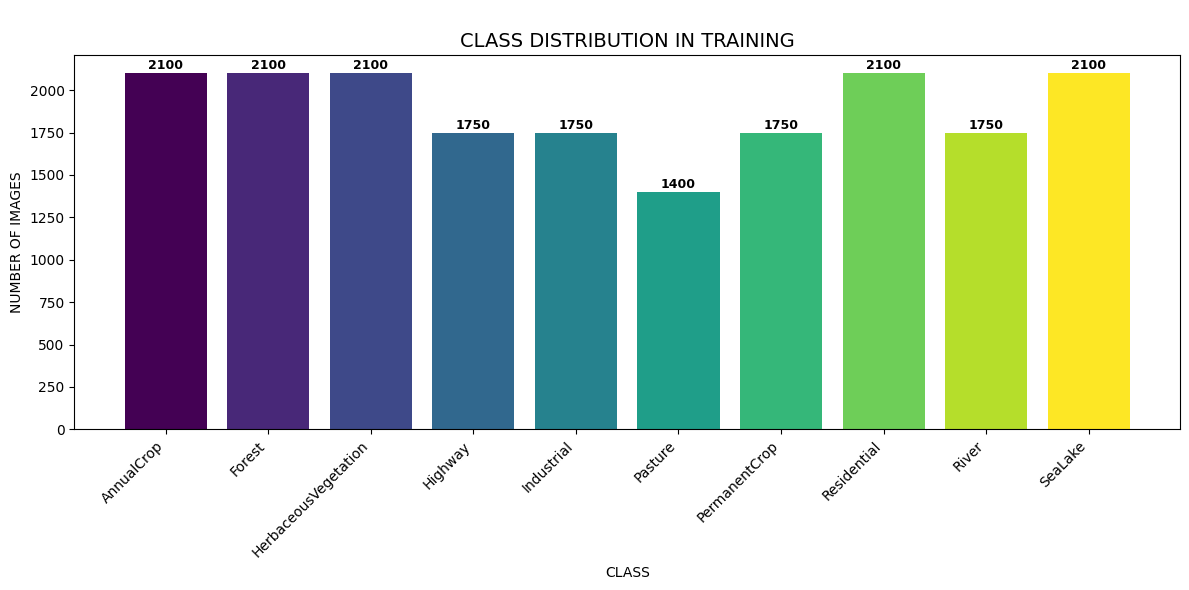


CLASS DISTRIBUTION ANALYSIS IN VALIDATION : 
Total images: 5400
AnnualCrop                (Label 0):  600 images (11.1%)
Forest                    (Label 1):  600 images (11.1%)
HerbaceousVegetation      (Label 2):  600 images (11.1%)
Highway                   (Label 3):  500 images (9.3%)
Industrial                (Label 4):  500 images (9.3%)
Pasture                   (Label 5):  400 images (7.4%)
PermanentCrop             (Label 6):  500 images (9.3%)
Residential               (Label 7):  600 images (11.1%)
River                     (Label 8):  500 images (9.3%)
SeaLake                   (Label 9):  600 images (11.1%)


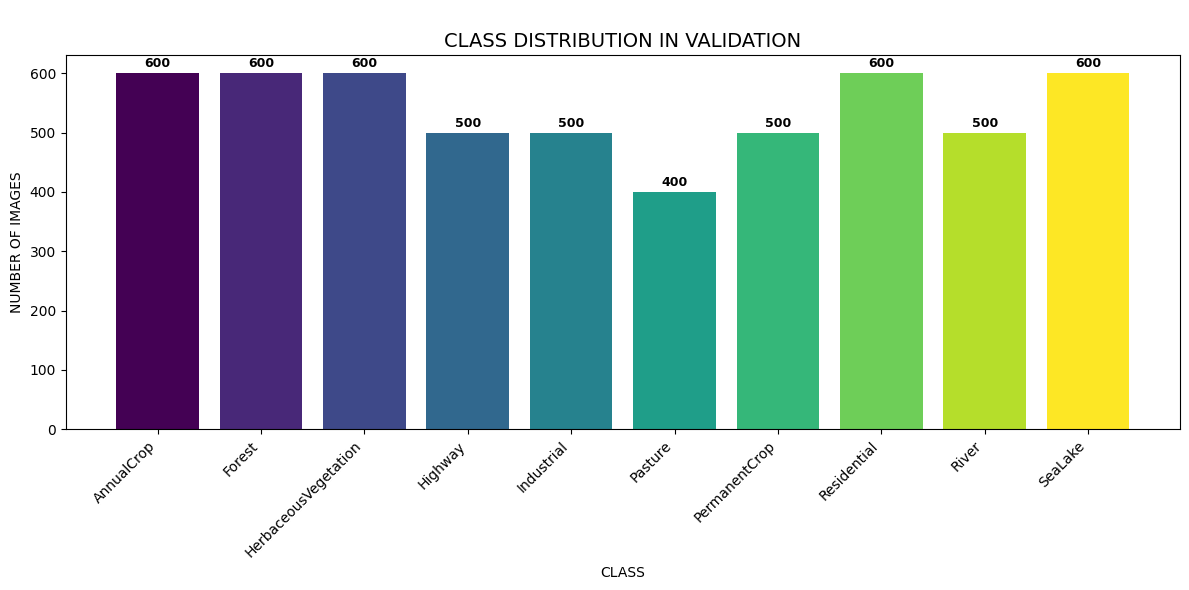


CLASS DISTRIBUTION ANALYSIS IN TEST : 
Total images: 2700
AnnualCrop                (Label 0):  300 images (11.1%)
Forest                    (Label 1):  300 images (11.1%)
HerbaceousVegetation      (Label 2):  300 images (11.1%)
Highway                   (Label 3):  250 images (9.3%)
Industrial                (Label 4):  250 images (9.3%)
Pasture                   (Label 5):  200 images (7.4%)
PermanentCrop             (Label 6):  250 images (9.3%)
Residential               (Label 7):  300 images (11.1%)
River                     (Label 8):  250 images (9.3%)
SeaLake                   (Label 9):  300 images (11.1%)


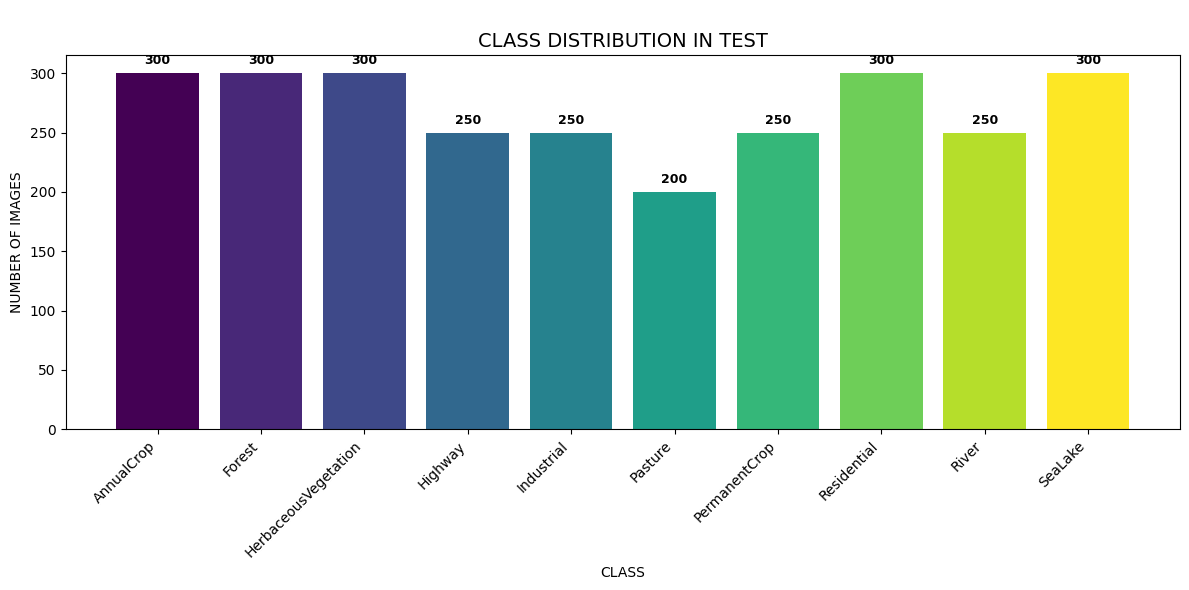

In [ ]:
########## "analyse_class_distribution(df, df_name)"
# Function to analyze and visualize class distribution in a dataset
# This is crucial for identifying potential class imbalance before model training

def analyse_class_distribution(df, df_name):
  print(f"\nCLASS DISTRIBUTION ANALYSIS IN {df_name} : ")

  # Count occurrences of each label to get class distribution
  class_distribution = df['Label'].value_counts().sort_index()

  # Create mapping from numeric labels to human-readable class names
  class_names_map = {}
  for label_id in class_distribution.index:
    class_name = df[df['Label'] == label_id]['ClassName'].iloc[0]
    class_names_map[label_id] = class_name

  # Display total number of images in the dataset
  total = len(df)
  print(f"Total images: {total}")

  # Print detailed statistics for each class
  for label_id, count in class_distribution.items():
    percentage = (count / total) * 100
    class_name = class_names_map[label_id]
    print(f"{class_name:25} (Label {label_id}): {count:4} images ({percentage:.1f}%)")

  # VISUALIZATION
  plt.figure(figsize=(12, 6))
  colors = plt.cm.viridis(np.linspace(0, 1, len(class_distribution.index)))

  bars = plt.bar(
      [class_names_map[label_id] for label_id in class_distribution.index],
      class_distribution.values,
      color=colors
      )

  plt.title(f"\nCLASS DISTRIBUTION IN {df_name}", fontsize=14)
  plt.xlabel('CLASS')
  plt.ylabel("NUMBER OF IMAGES")
  plt.xticks(rotation=45, ha='right')

  for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2., height + 5, f'{int(height)}', ha='center', va='bottom', fontsize=9, fontweight='bold')

  plt.tight_layout()
  plt.show()

  return class_distribution, class_names_map

train_dist, train_class_names = analyse_class_distribution(train_data, "TRAINING")
Val_dist, Val_class_names = analyse_class_distribution(validation_data, "VALIDATION")
test_dist, test_class_names = analyse_class_distribution(test_data, "TEST")

The class distribution analysis shows that the EuroSAT dataset is **well balanced** across all three splits: training, validation, and test.

 - In the training set, most classes represent around **9% to 11%** of the total images.  
     - Classes such as *AnnualCrop*, *Forest*, *HerbaceousVegetation*, *Residential*, and *SeaLake* are the most represented (11.1%), while *Pasture* is the least represented class (7.4%).

- The validation and test sets follow **exactly the same distribution pattern** as the training set. This indicates that the dataset splitting strategy preserves the original class proportions and avoids distribution shift between splits.

Overall, the slight class imbalance observed is **limited** and unlikely to strongly bias the training process.  
However, the lower representation of the *Pasture* class may still make its classification slightly more challenging compared to other classes.


## *4b. Image - Visualisation*

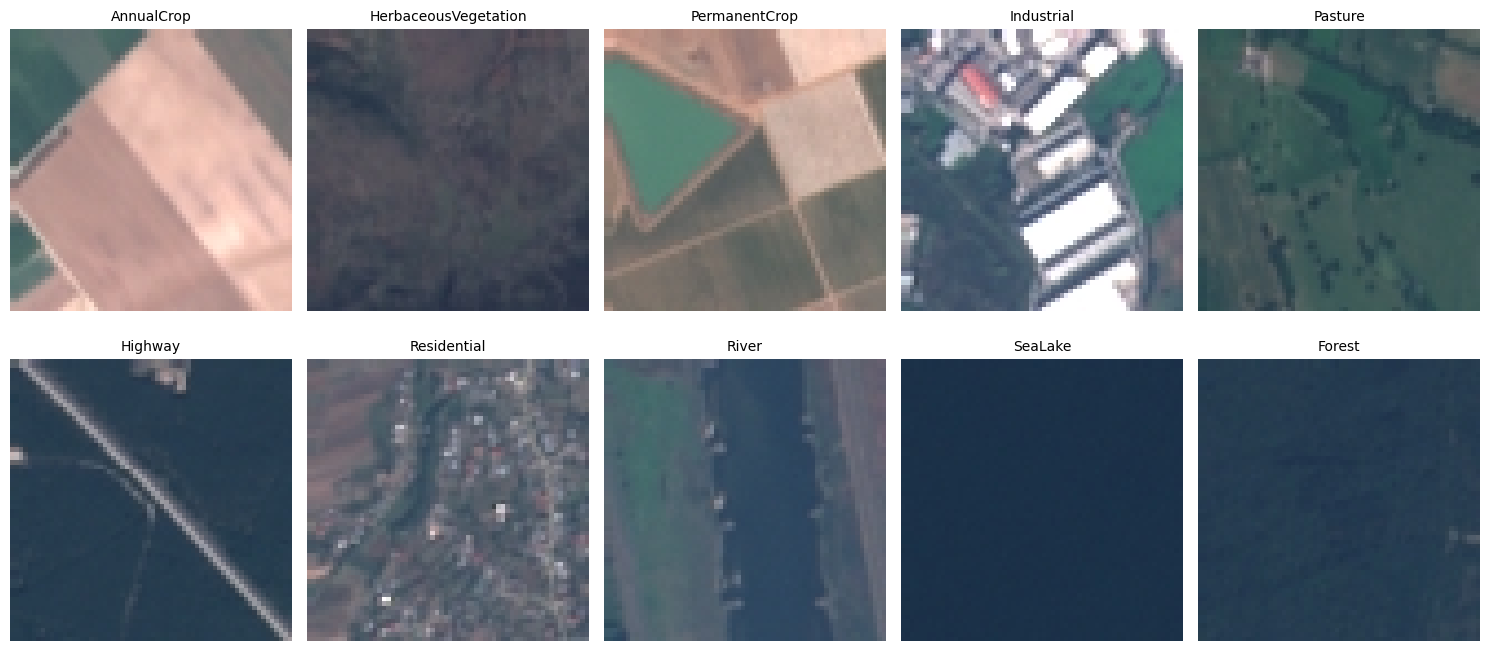

In [ ]:
unique_classes = train_data['ClassName'].unique()

fig, axes = plt.subplots(2, 5, figsize=(15, 7))
axes = axes.flatten()

for i, label in enumerate(unique_classes):
    # For each class, we select the first image
    sample = train_data[train_data['ClassName'] == label].iloc[0]

    img_path = os.path.join(data_dir, sample['Filename'])
    image = Image.open(img_path).convert("RGB")

    axes[i].imshow(image)
    axes[i].set_title(label, fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.show()


# **5. Data Preprocessing and augmentation for training set**
---
---

## *5a. Input Transformations and Data Augmentation*

Before training the models, input images must be transformed into a format suitable for deep learning.

We define two transformation pipelines:
- one **with data augmentation**, used only for the training set,
- one **without augmentation**, used for validation and test sets.

All images are resized to **64×64 pixels** and normalized using ImageNet statistics.  
This normalization helps stabilizing training and ensures compatibility with pre-trained CNN architectures.

Data augmentation is applied only during training in order to:
- increase data variability,
- improve model generalization,
- reduce overfitting.

For satellite images, we apply **safe and realistic augmentations**, such as horizontal and vertical flips and very mild color variations.  
These transformations preserve the semantic meaning of the land-use classes.


In [ ]:
######## With Augmentation
transform_aug = transforms.Compose([
    transforms.Resize((64,64)),

    # Safe augmentations for satellite images
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomChoice([
        transforms.RandomRotation((0, 0)),
        transforms.RandomRotation((90, 90)),
        transforms.RandomRotation((180, 180)),
        transforms.RandomRotation((270, 270))
    ]),
    # Very mild color changes
    transforms.ColorJitter(
        brightness=0.05,
        contrast=0.05,
        saturation=0.02
    ),

    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225])
])

######## No augmentation
transform_no_aug = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225])
])

## *5b. Create Datasets and Dataloaders*

In this section, we define a custom PyTorch `Dataset` (`EuroSATDataset`) to load images and labels from the CSV files. Image transformations are applied inside the dataset to ensure consistent preprocessing.

PyTorch `DataLoader`s are also used to enable efficient batch processing. The training DataLoader uses shuffling to improve model generalization but Validation and test DataLoaders do not use shuffling to ensure stable and reproducible evaluation.


In [ ]:
################## Class "EuroSATDataset" : This class defines how to load images and labels from the dataframe
class EuroSATDataset(Dataset):
  def __init__(self, df, data_dir, transform=None):
    self.df = df                 # DataFrame containing filenames and labels
    self.data_dir = data_dir     # Root directory for image files
    self.transform = transform   # Transformation pipeline to apply

  def __len__(self):
    # Returns total number of samples in the dataset
    return len(self.df)

  def __getitem__(self, index):
    img_path = os.path.join(self.data_dir, self.df.iloc[index]['Filename'])
    image = Image.open(img_path).convert("RGB")
    label = self.df.iloc[index]['Label']

    if self.transform:
      image = self.transform(image)
    return image, label

In [ ]:
################## Dataset Instances Creation
train_dataset_aug = EuroSATDataset(train_data, data_dir, transform=transform_aug)
validation_dataset = EuroSATDataset(validation_data, data_dir, transform=transform_no_aug)
test_dataset = EuroSATDataset(test_data, data_dir, transform=transform_no_aug)

################# DataLoader Initialization
# Create DataLoaders for efficient batch processing during training/validation/testing
train_loader_aug = DataLoader(train_dataset_aug, batch_size=32, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

## *5c. Training Setup: Device and Loss Function*

- GPU (CUDA) is used when available to speed up model training.
- CPU is used as a fallback when no GPU is detected.
- The loss function used is **CrossEntropyLoss**, which is standard for multi-class classification tasks.


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = torch.nn.CrossEntropyLoss()

## *5d. Original vs Augmented Images**


- This comparison verifies that data augmentation:
  - is effectively applied,
  - preserves the semantic meaning of each class,
  - does not introduce unrealistic artifacts.

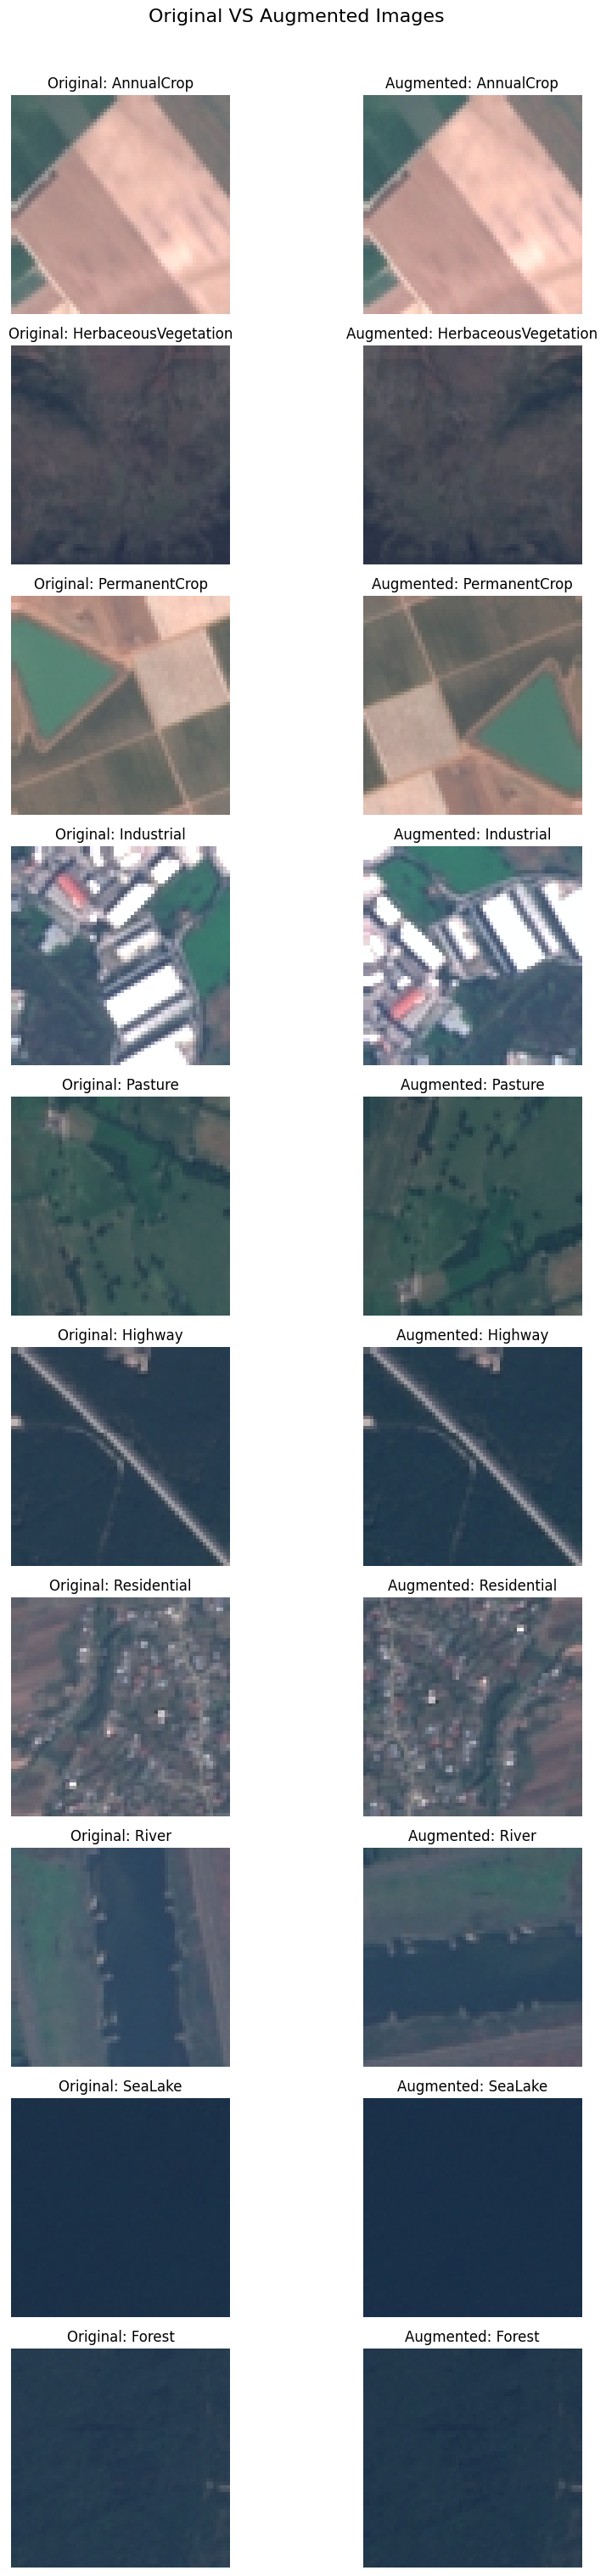

In [ ]:
########## Visualization: Original vs Augmented Images
# Compare original images with their augmented versions to verify data augmentation pipeline
# This helps confirm that augmentations are applied correctly without distorting image semantics

unique_classes = train_data['ClassName'].unique()
num_images = len(unique_classes) # Saranno 10

# ImageNet normalization statistics (used to denormalize images for visualization)
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

# Fix: Changed subplot dimensions to (num_images, 2) instead of (2, num_images)
fig, axes = plt.subplots(num_images, 2, figsize=(10, 3 * num_images))

for idx, class_name in enumerate(unique_classes):

    original_df_idx = train_data[train_data['ClassName'] == class_name].index[0]

    # ======================
    # BEFORE : raw img
    # ======================
    img_path = os.path.join(
        data_dir,
        train_data.loc[original_df_idx, "Filename"]
    )
    original_image = Image.open(img_path).convert("RGB")
    original_image = original_image.resize((64, 64)) # Per coerenza visiva

    axes[idx, 0].imshow(original_image)
    axes[idx, 0].set_title(f"Original: {class_name}")
    axes[idx, 0].axis("off")

    # ======================
    # AFTER : augmented img
    # ======================
    img_aug, label_idx = train_dataset_aug[original_df_idx]

    img_np_aug = img_aug.permute(1, 2, 0).numpy()

    img_np_aug = std * img_np_aug + mean
    img_np_aug = np.clip(img_np_aug, 0, 1)

    axes[idx, 1].imshow(img_np_aug)
    axes[idx, 1].set_title(f"Augmented: {class_name}")
    axes[idx, 1].axis("off")

plt.suptitle("Original VS Augmented Images", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

The results confirm that the augmentation strategy is appropriate for satellite imagery.


Summary of this section


---



---


| Category            | Variable Name        | Purpose                                      | Notes                                   |
| ------------------- | -------------------- | -------------------------------------------- | --------------------------------------- |
| **Device**          | `device`             | Selects CPU or GPU for training              | `cuda` if available, else `cpu`         |
| **Transforms**      | `transform_aug`      | Applies data augmentation to training images | Used **only for training**              |
| **Transforms**      | `transform_no_aug`   | Standard preprocessing without augmentation  | Used for **validation & test only**     |
| **Dataset**         | `train_dataset`      | Training dataset with augmentation           | Based on `train_data`                   |
| **Dataset**         | `validation_dataset` | Validation dataset without augmentation      | Fixed order                             |
| **Dataset**         | `test_dataset`       | Test dataset without augmentation            | Fixed order                             |
| **DataLoader**      | `train_loader`       | Loads training batches                       | `shuffle=True`                          |
| **DataLoader**      | `validation_loader`  | Loads validation batches                     | `shuffle=False`                         |
| **DataLoader**      | `test_loader`        | Loads test batches                           | `shuffle=False`                         |
| **Loss Function**   | `criterion`          | Computes classification loss                 | `CrossEntropyLoss()` (no class weights) |
| **Training Params** | `batch_size`         | Number of images per batch                   | 32                                      |
| **Labels**          | `label_idx`          | Numeric class index                          | Used to fetch class name                |
| **Labels**          | `train_class_names`  | Maps label index to class name               | For visualization only                  |


# **6. Models**

The goal of this project is to classify land-use types from satellite images and return the most likely class for each image. This task involves recognizing visual patterns such as textures, shapes, and spatial structures that can vary significantly across land-use categories.  Some classes are visually distinct (e.g., SeaLake or Residential), while others share similar visual characteristics (e.g., agricultural and vegetation areas).

To address this problem, we evaluate different convolutional neural network (CNN) architectures with increasing complexity.  

##  ***Model 1 : LeNet**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 10

#LeNet for RGB images 64x64
class LeNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 6, kernel_size=5)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)

        self.fc1 = nn.Linear(16 * 13 * 13, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)

        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x

#Training LeNet
model = LeNet(num_classes=10)
model = model.to(device)

###**EXECUTE THE FOLLOWING ONLY IF YOU NEED TO TRAIN THE MODEL AGAIN**

### Training LeNet

In [ ]:
# Loss and optimizer
criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Training parameters
num_epochs = 20
train_loader = train_loader_aug
val_loader = validation_loader
best_val_acc = 0

# Compute accuracy
def compute_accuracy(outputs, labels):
    _, preds = torch.max(outputs, 1)
    correct = (preds == labels).sum().item()
    total = labels.size(0)
    return correct / total

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Training loop
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    train_acc = 0.0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        train_acc += compute_accuracy(outputs, labels) * images.size(0)

    train_loss /= len(train_loader.dataset)
    train_acc /= len(train_loader.dataset)

    # Validation
    model.eval()
    val_loss = 0.0
    val_acc = 0.0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]"):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            val_acc += compute_accuracy(outputs, labels) * images.size(0)

    val_loss /= len(val_loader.dataset)
    val_acc /= len(val_loader.dataset)

    print(f"Epoch {epoch+1}/{num_epochs}: "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

#code to save the characteristics of the best model on Cristina's drive
    if val_acc > best_val_acc:
      best_val_acc = val_acc
      torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies
      }, "/content/drive/MyDrive/ML-BIANCHINI/lenet_checkpoint.pth")



Epoch 1/20 [Val]: 100%|██████████| 169/169 [00:10<00:00, 16.40it/s]


Epoch 1/20: Train Loss: 0.4889, Train Acc: 0.8233, Val Loss: 0.5064, Val Acc: 0.8263


Epoch 2/20 [Val]: 100%|██████████| 169/169 [00:09<00:00, 18.29it/s]


Epoch 2/20: Train Loss: 0.4692, Train Acc: 0.8308, Val Loss: 0.5942, Val Acc: 0.7806


Epoch 3/20 [Val]: 100%|██████████| 169/169 [00:10<00:00, 16.68it/s]


...

Epoch 18/20: Train Loss: 0.3521, Train Acc: 0.8740, Val Loss: 0.4319, Val Acc: 0.8478


Epoch 19/20 [Val]: 100%|██████████| 169/169 [00:08<00:00, 20.39it/s]


Epoch 19/20: Train Loss: 0.3453, Train Acc: 0.8762, Val Loss: 0.4367, Val Acc: 0.8494


Epoch 20/20 [Val]: 100%|██████████| 169/169 [00:08<00:00, 20.73it/s]

Epoch 20/20: Train Loss: 0.3391, Train Acc: 0.8795, Val Loss: 0.4026, Val Acc: 0.8535


###**EXECUTE THE FOLLOWING TO IMPORT THE ALREADY EXISTING LENET TRAINED MODEL AND VARIABLES**

In [ ]:
#checkpoint = torch.load("/content/drive/MyDrive/unistra/M2/Projet de groupe/ML-BIANCHINI/lenet_checkpoint.pth", map_location=device)
checkpoint = torch.load("/content/drive/MyDrive/ML-BIANCHINI/lenet_checkpoint.pth", map_location = device)

# Initialized model
model = LeNet(num_classes=num_classes) # Assuming LeNet class and num_classes are defined.
model = model.to(device)

# Initiated optimizer (parameters are loaded from checkpoint later)
optimizer = optim.Adam(model.parameters(), lr=1e-3) # Learning rate can be arbitrary here, as it will be overwritten.

model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

train_losses = checkpoint['train_losses']
val_losses = checkpoint['val_losses']
train_accuracies = checkpoint['train_accuracies']
val_accuracies = checkpoint['val_accuracies']

print("LeNet model and optimizer states loaded successfully.")

LeNet model and optimizer states loaded successfully.


### Training Results

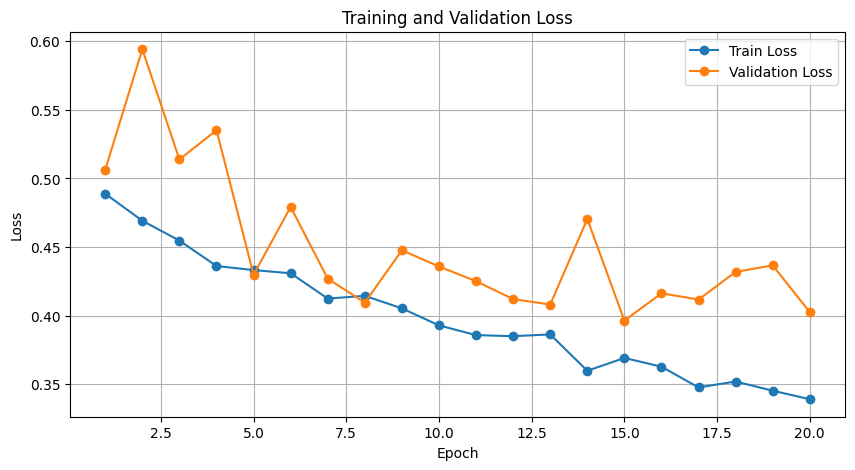

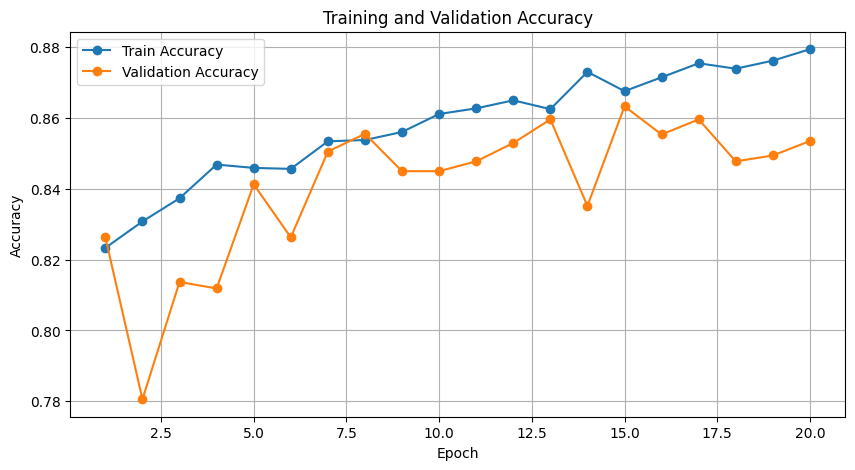

In [ ]:
epochs = range(1, len(train_losses) + 1)

# --- Loss ---
plt.figure(figsize=(10,5))
plt.plot(epochs, train_losses, label='Train Loss', marker='o')
plt.plot(epochs, val_losses, label='Validation Loss', marker='o')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# --- Accuracy ---
plt.figure(figsize=(10,5))
plt.plot(epochs, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(epochs, val_accuracies, label='Validation Accuracy', marker='o')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


LeNet was used as the baseline model, but didn't perform well enough, stabilizing around 85% of accuracy on validation set.

Validation curves follow the Training curves, so the model is actually learning.
Validation curves continue to improve until epoch 15, but in the later epochs the model slightly overfits and the performances get worse.

Other CNNs are then explored to search for better results.

## ***Model 2 : ResNet18**

In [ ]:
def build_resnet18(num_classes=10, device='cpu'):
    # ResNet18 pre-trained
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    # Substitute the last fully connected layer
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    model = model.to(device)
    return model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = build_resnet18(num_classes=10, device=device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 93.8MB/s]


In [ ]:
for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True


In [ ]:
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

In [ ]:
# Composition of the ResNet18 (it shows all the layers)
summary(model, input_size=(3, 64, 64))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           9,408
       BatchNorm2d-2           [-1, 64, 32, 32]             128
              ReLU-3           [-1, 64, 32, 32]               0
         MaxPool2d-4           [-1, 64, 16, 16]               0
            Conv2d-5           [-1, 64, 16, 16]          36,864
       BatchNorm2d-6           [-1, 64, 16, 16]             128
              ReLU-7           [-1, 64, 16, 16]               0
            Conv2d-8           [-1, 64, 16, 16]          36,864
       BatchNorm2d-9           [-1, 64, 16, 16]             128
             ReLU-10           [-1, 64, 16, 16]               0
       BasicBlock-11           [-1, 64, 16, 16]               0
           Conv2d-12           [-1, 64, 16, 16]          36,864
      BatchNorm2d-13           [-1, 64, 16, 16]             128
             ReLU-14           [-1, 64,

###**EXECUTE THE FOLLOWING ONLY IF THE MODEL HAS TO BE TRAINED AGAIN**

### Training ResNet18

In [ ]:
num_epochs = 8
train_loader = train_loader_aug
val_loader = validation_loader

# Lists to save metrics for plotting
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
best_val_acc = 0

for epoch in range(num_epochs):
    # ---- TRAIN ----
    model.train()
    train_loss = 0.0
    train_acc = 0.0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        train_acc += compute_accuracy(outputs, labels) * images.size(0)

    train_loss /= len(train_loader.dataset)
    train_acc /= len(train_loader.dataset)

    # ---- VALIDATION ----
    model.eval()
    val_loss = 0.0
    val_acc = 0.0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            val_acc += compute_accuracy(outputs, labels) * images.size(0)

    val_loss /= len(val_loader.dataset)
    val_acc /= len(val_loader.dataset)

    # ---- SAVE METRICS ----
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs}: "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    if val_acc > best_val_acc:
      best_val_acc = val_acc
      torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies
      }, "/content/drive/MyDrive/ML-BIANCHINI/resnet_checkpoint.pth")


Epoch 1/8 [Val]: 100%|██████████| 169/169 [00:58<00:00,  2.89it/s]


Epoch 1/8: Train Loss: 0.4264, Train Acc: 0.8593 | Val Loss: 0.2063, Val Acc: 0.9298


Epoch 2/8 [Val]: 100%|██████████| 169/169 [00:58<00:00,  2.89it/s]


Epoch 2/8: Train Loss: 0.2349, Train Acc: 0.9199 | Val Loss: 0.1605, Val Acc: 0.9467


Epoch 3/8 [Val]: 100%|██████████| 169/169 [00:56<00:00,  2.99it/s]


...

Epoch 6/8: Train Loss: 0.1356, Train Acc: 0.9535 | Val Loss: 0.1391, Val Acc: 0.9550


Epoch 7/8 [Val]: 100%|██████████| 169/169 [00:56<00:00,  3.01it/s]


Epoch 7/8: Train Loss: 0.1236, Train Acc: 0.9567 | Val Loss: 0.1325, Val Acc: 0.9519


Epoch 8/8 [Val]: 100%|██████████| 169/169 [00:56<00:00,  3.01it/s]


Epoch 8/8: Train Loss: 0.1107, Train Acc: 0.9618 | Val Loss: 0.1265, Val Acc: 0.9596


###**EXECUTE THE FOLLOWING TO IMPORT THE ALREADY EXISTING RESNET TRAINED MODEL AND VARIABLES**

In [ ]:
#checkpoint = torch.load("/content/drive/MyDrive/unistra/M2/Projet de groupe/ML-BIANCHINI/resnet_checkpoint.pth", map_location=device)
checkpoint = torch.load("/content/drive/MyDrive/ML-BIANCHINI/resnet_checkpoint.pth", map_location = device)

# The model should have been initialized and its layers frozen/unfrozen in previous "Must run" cells.
# We load the state dict of the model first.
model.load_state_dict(checkpoint['model_state_dict'])

# Re-initialize the optimizer with the current model parameters that have requires_grad=True.
# This step is crucial to ensure the optimizer's parameter groups match the current trainable parameters of the model
# before loading its saved state.
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4 # Using the learning rate specified in the training cells for ResNet18
)

optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

train_losses = checkpoint['train_losses']
val_losses = checkpoint['val_losses']
train_accuracies = checkpoint['train_accuracies']
val_accuracies = checkpoint['val_accuracies']

print("ResNet model and optimizer states loaded successfully.")

ResNet model and optimizer states loaded successfully.


### Training Results

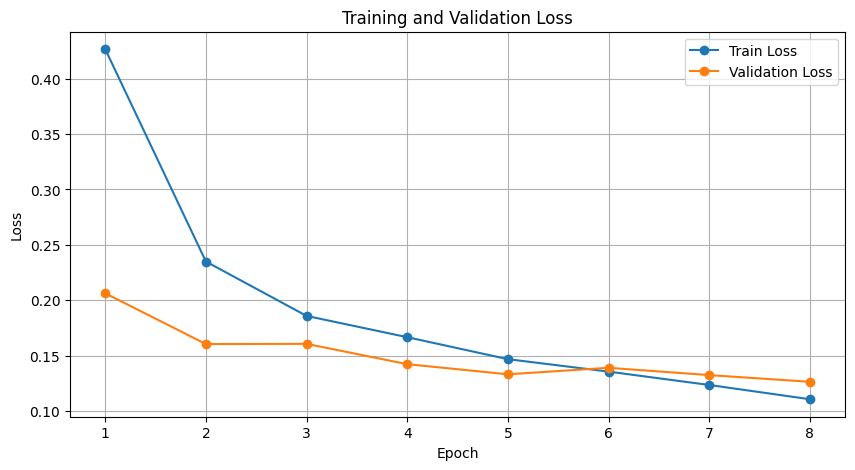

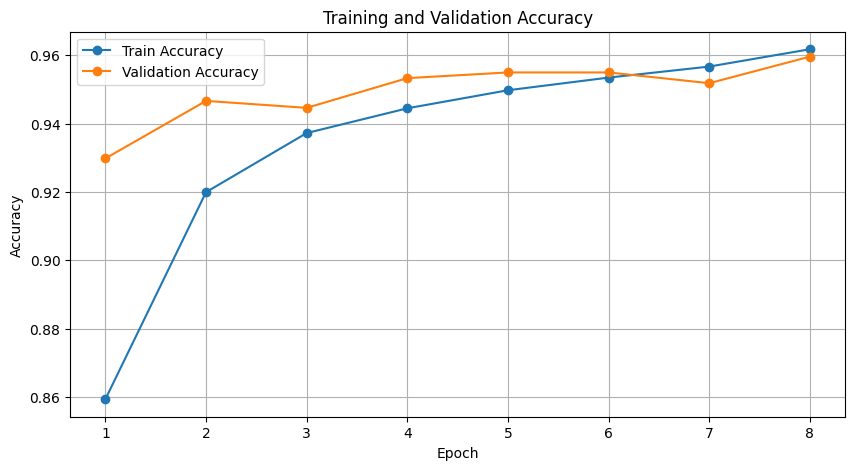

In [ ]:
epochs = range(1, len(train_losses) + 1)

# --- Loss ---
plt.figure(figsize=(10,5))
plt.plot(epochs, train_losses, label='Train Loss', marker='o')
plt.plot(epochs, val_losses, label='Validation Loss', marker='o')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# --- Accuracy ---
plt.figure(figsize=(10,5))
plt.plot(epochs, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(epochs, val_accuracies, label='Validation Accuracy', marker='o')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


ResNet reaches better results, scoring around 95% of accuracy on Validation set.

Only 8 epochs were tested because in later epochs the model overfits.

## ***Model 3 : EfficientNet**

In [ ]:
def build_efficientnet(num_classes=10, device='cpu'):
    # Upload pre-trained EfficientNet-B0
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

    # Substitute the last layer (classifier) with the number of classes of EuroSAT
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)

    model = model.to(device)

    return model

In [ ]:
model = build_efficientnet(num_classes=10, device=device)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 147MB/s]


In [ ]:
for param in model.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

for param in model.features[-2:].parameters():
    param.requires_grad = True


In [ ]:
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

In [ ]:
# Composition of the EfficientNet-B0
summary(model, input_size=(3, 64, 64))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             864
       BatchNorm2d-2           [-1, 32, 32, 32]              64
              SiLU-3           [-1, 32, 32, 32]               0
            Conv2d-4           [-1, 32, 32, 32]             288
       BatchNorm2d-5           [-1, 32, 32, 32]              64
              SiLU-6           [-1, 32, 32, 32]               0
 AdaptiveAvgPool2d-7             [-1, 32, 1, 1]               0
            Conv2d-8              [-1, 8, 1, 1]             264
              SiLU-9              [-1, 8, 1, 1]               0
           Conv2d-10             [-1, 32, 1, 1]             288
          Sigmoid-11             [-1, 32, 1, 1]               0
SqueezeExcitation-12           [-1, 32, 32, 32]               0
           Conv2d-13           [-1, 16, 32, 32]             512
      BatchNorm2d-14           [-1, 16,

###**EXECUTE THE FOLLOWING ONLY IF THE MODEL HAS TO BE TRAINED AGAIN**

### Training EfficientNet

In [ ]:
num_epochs = 15

# Lists to save metrics for plotting
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
best_val_acc = 0

for epoch in range(num_epochs):
    # ---- TRAIN ----
    model.train()
    train_loss = 0.0
    train_acc = 0.0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        train_acc += compute_accuracy(outputs, labels) * images.size(0)

    train_loss /= len(train_loader.dataset)
    train_acc /= len(train_loader.dataset)

    # ---- VALIDATION ----
    model.eval()
    val_loss = 0.0
    val_acc = 0.0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            val_acc += compute_accuracy(outputs, labels) * images.size(0)

    val_loss /= len(val_loader.dataset)
    val_acc /= len(val_loader.dataset)

    # ---- SAVE METRICS ----
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs}: "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
      best_val_acc = val_acc
      torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies
      }, "/content/drive/MyDrive/ML-BIANCHINI/efficientnet_checkpoint.pth")

Epoch 1/15 [Val]: 100%|██████████| 169/169 [00:36<00:00,  4.58it/s]


Epoch 1/15: Train Loss: 0.9702, Train Acc: 0.7061 | Val Loss: 0.4636, Val Acc: 0.8617


Epoch 2/15 [Val]: 100%|██████████| 169/169 [00:35<00:00,  4.76it/s]


Epoch 2/15: Train Loss: 0.5230, Train Acc: 0.8277 | Val Loss: 0.3654, Val Acc: 0.8852


Epoch 3/15 [Val]: 100%|██████████| 169/169 [00:34<00:00,  4.86it/s]


...

Epoch 13/15: Train Loss: 0.2943, Train Acc: 0.8988 | Val Loss: 0.2260, Val Acc: 0.9235


Epoch 14/15 [Val]: 100%|██████████| 169/169 [00:35<00:00,  4.73it/s]


Epoch 14/15: Train Loss: 0.2783, Train Acc: 0.9014 | Val Loss: 0.2226, Val Acc: 0.9235


Epoch 15/15 [Val]: 100%|██████████| 169/169 [00:35<00:00,  4.72it/s]


Epoch 15/15: Train Loss: 0.2824, Train Acc: 0.9031 | Val Loss: 0.2096, Val Acc: 0.9283


###**EXECUTE THE FOLLOWING TO IMPORT THE ALREADY EXISTING EFFICIENTNET TRAINED MODEL AND VARIABLES**

In [ ]:
#checkpoint = torch.load("/content/drive/MyDrive/unistra/M2/Projet de groupe/ML-BIANCHINI/efficientnet_checkpoint.pth", map_location=device)
checkpoint = torch.load("/content/drive/MyDrive/ML-BIANCHINI/efficientnet_checkpoint.pth", map_location = device)

model.load_state_dict(checkpoint['model_state_dict'])

# Re-initialize the optimizer with the current model parameters that have requires_grad=True.
# This step is crucial to ensure the optimizer's parameter groups match the current trainable parameters of the model
# before loading its saved state.
# The `lr` should match the one used during training the EfficientNet model, which was 1e-4.
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

train_losses = checkpoint['train_losses']
val_losses = checkpoint['val_losses']
train_accuracies = checkpoint['train_accuracies']
val_accuracies = checkpoint['val_accuracies']

print("EfficientNet-B0 model and optimizer states loaded successfully.")

EfficientNet-B0 model and optimizer states loaded successfully.


### Training Results

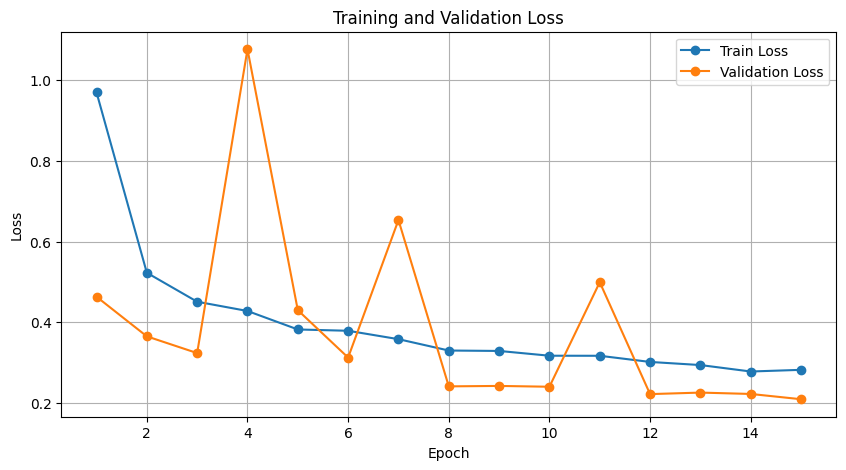

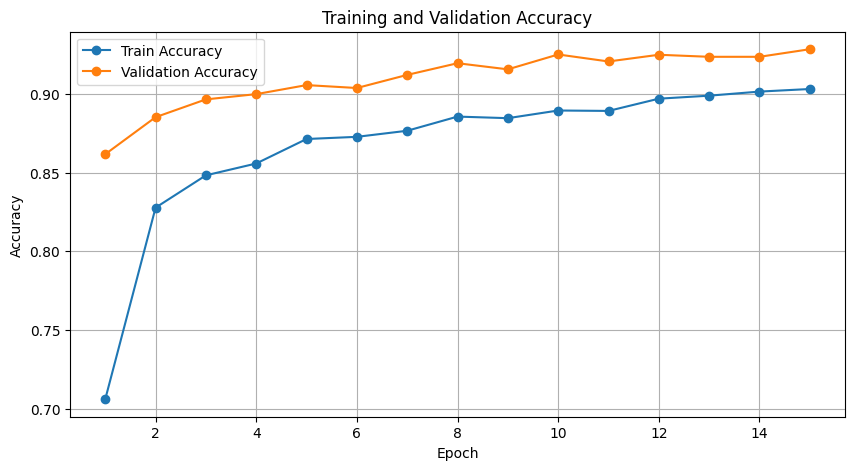

In [ ]:
epochs = range(1, len(train_losses) + 1)

# --- Loss ---
plt.figure(figsize=(10,5))
plt.plot(epochs, train_losses, label='Train Loss', marker='o')
plt.plot(epochs, val_losses, label='Validation Loss', marker='o')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# --- Accuracy ---
plt.figure(figsize=(10,5))
plt.plot(epochs, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(epochs, val_accuracies, label='Validation Accuracy', marker='o')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


EfficientNet-B0 was tested and it obtained an accuracy around 92%.

The Validation Accuracy curve is always above the Training Accuracy curve, probably due to the augmentation of the images in the Training set and not in the Validation one.

Still, the performance of the net in the Validation set is high and it stabilizes around 92%.

# **7. EVALUATION**

In [ ]:
lenet_model = LeNet(num_classes=10).to(device)
resnet_model = build_resnet18(num_classes=10, device=device)
efficientnet_model = build_efficientnet(num_classes=10, device=device)


##### Chargement des modèles depuis le drive
# Essi's paths
#lenet_ckpt_path = "/content/drive/MyDrive/unistra/M2/Projet de groupe/ML-BIANCHINI/lenet_checkpoint.pth"
#resnet_ckpt_path = "/content/drive/MyDrive/unistra/M2/Projet de groupe/ML-BIANCHINI/resnet_checkpoint.pth"
#efficientnet_ckpt_path = "/content/drive/MyDrive/unistra/M2/Projet de groupe/ML-BIANCHINI/efficientnet_checkpoint.pth"

#Cristina's paths
lenet_ckpt_path = "/content/drive/MyDrive/ML-BIANCHINI/lenet_checkpoint.pth"
resnet_ckpt_path = "/content/drive/MyDrive/ML-BIANCHINI/resnet_checkpoint.pth"
efficientnet_ckpt_path = "/content/drive/MyDrive/ML-BIANCHINI/efficientnet_checkpoint.pth"

print("LeNet :", os.path.exists(lenet_ckpt_path))
print("ResNet :", os.path.exists(resnet_ckpt_path))
print("EfficientNet :", os.path.exists(efficientnet_ckpt_path))

lenet_ckpt = torch.load(lenet_ckpt_path, map_location=device)
resnet_ckpt = torch.load(resnet_ckpt_path, map_location=device)
effnet_ckpt = torch.load(efficientnet_ckpt_path, map_location=device)

lenet_model.load_state_dict(lenet_ckpt["model_state_dict"])
resnet_model.load_state_dict(resnet_ckpt["model_state_dict"])
efficientnet_model.load_state_dict(effnet_ckpt["model_state_dict"])

print("Class Name Mapping (Label: ClassName):")
for label_id, class_name in train_class_names.items():
    print(f"  Label {label_id}: {class_name}")


LeNet : True
ResNet : True
EfficientNet : True
Class Name Mapping (Label: ClassName):
  Label 0: AnnualCrop
  Label 1: Forest
  Label 2: HerbaceousVegetation
  Label 3: Highway
  Label 4: Industrial
  Label 5: Pasture
  Label 6: PermanentCrop
  Label 7: Residential
  Label 8: River
  Label 9: SeaLake


In [ ]:
# Define the official list of class names, ordered by their labels

ClassName = [train_class_names[i] for i in sorted(train_class_names.keys())]
print("Official list of Class Names:", ClassName)

Official list of Class Names: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [ ]:
def evaluate_model(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)

def compute_metrics(y_true, y_pred, class_names):
    acc = accuracy_score(y_true, y_pred)

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    report_df = pd.DataFrame(report_dict).T
    return acc, report_df


def plot_confusion(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10,8))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d', # Changed gfmt to fmt
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel("Predicted Classes")
    plt.ylabel("True Classes")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.show()

def full_evaluation(model, dataloader, class_names, device, model_name):
    y_true, y_pred = evaluate_model(model, dataloader, device)

    acc, report_df = compute_metrics(y_true, y_pred, class_names)

    print(f"\n===== {model_name} =====")
    print(f"Accuracy : {acc:.4f}")
    display(report_df)

    plot_confusion(
        y_true,
        y_pred,
        class_names,
        title=f"{model_name} – Confusion Matrix"
    )

    return acc, report_df



===== LeNet =====
Accuracy : 0.8541


,precision,recall,f1-score,support
AnnualCrop,0.875421,0.866667,0.871022,300.000000
Forest,0.950000,0.950000,0.950000,300.000000
HerbaceousVegetation,0.760383,0.793333,0.776509,300.000000
Highway,0.779487,0.608000,0.683146,250.000000
Industrial,0.907631,0.904000,0.905812,250.000000
Pasture,0.854369,0.880000,0.866995,200.000000
PermanentCrop,0.735409,0.756000,0.745562,250.000000
Residential,0.889881,0.996667,0.940252,300.000000
River,0.773946,0.808000,0.790607,250.000000
SeaLake,0.975524,0.930000,0.952218,300.000000


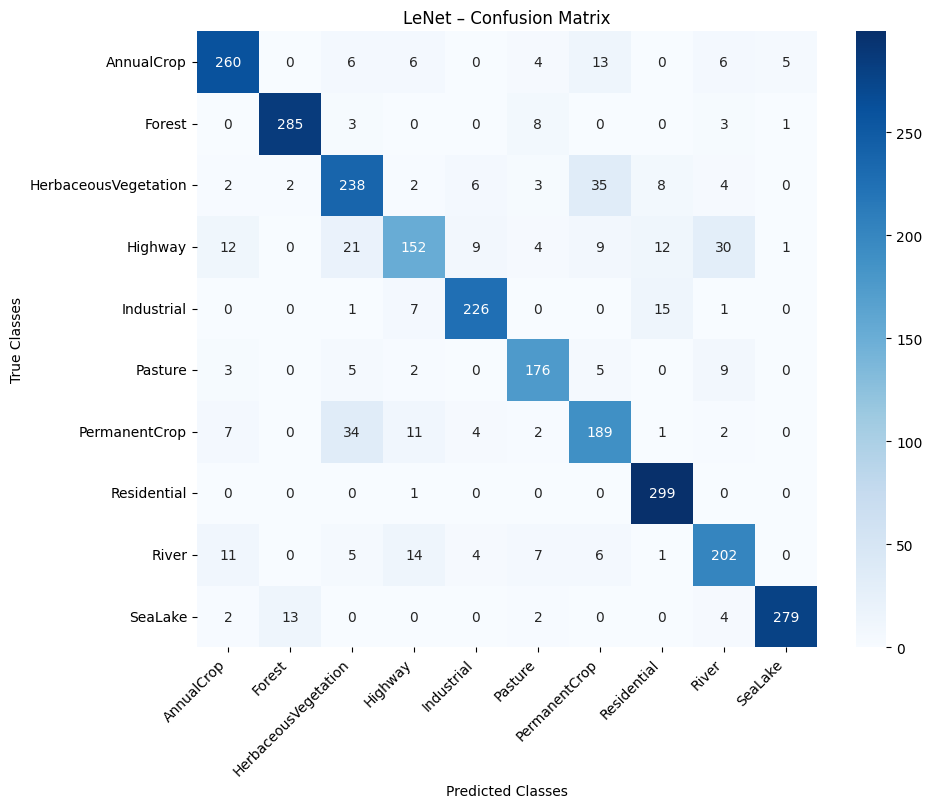


===== ResNet18 =====
Accuracy : 0.9652


,precision,recall,f1-score,support
AnnualCrop,0.948882,0.990000,0.969005,300.000000
Forest,0.993311,0.990000,0.991653,300.000000
HerbaceousVegetation,0.945338,0.980000,0.962357,300.000000
Highway,0.938776,0.920000,0.929293,250.000000
Industrial,0.983264,0.940000,0.961145,250.000000
Pasture,0.954774,0.950000,0.952381,200.000000
PermanentCrop,0.932540,0.940000,0.936255,250.000000
Residential,0.986711,0.990000,0.988353,300.000000
River,0.966805,0.932000,0.949084,250.000000
SeaLake,0.993333,0.993333,0.993333,300.000000


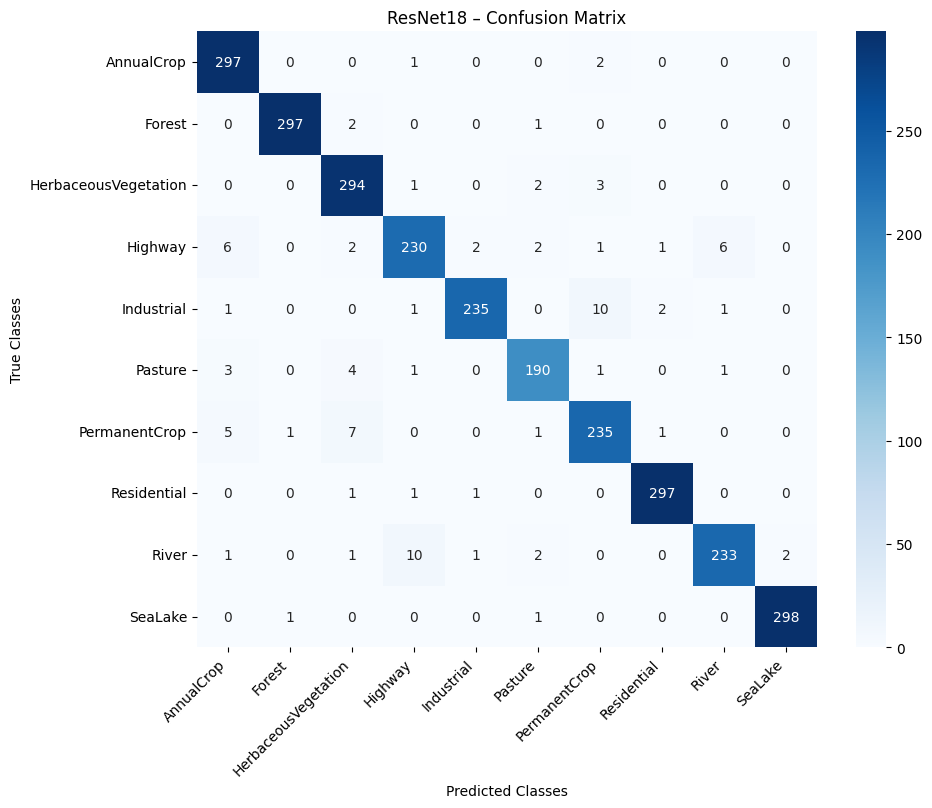


===== EfficientNet =====
Accuracy : 0.9378


,precision,recall,f1-score,support
AnnualCrop,0.953333,0.953333,0.953333,300.000000
Forest,0.960656,0.976667,0.968595,300.000000
HerbaceousVegetation,0.904605,0.916667,0.910596,300.000000
Highway,0.920168,0.876000,0.897541,250.000000
Industrial,0.956000,0.956000,0.956000,250.000000
Pasture,0.906404,0.920000,0.913151,200.000000
PermanentCrop,0.878431,0.896000,0.887129,250.000000
Residential,0.960265,0.966667,0.963455,300.000000
River,0.928287,0.932000,0.930140,250.000000
SeaLake,0.989726,0.963333,0.976351,300.000000


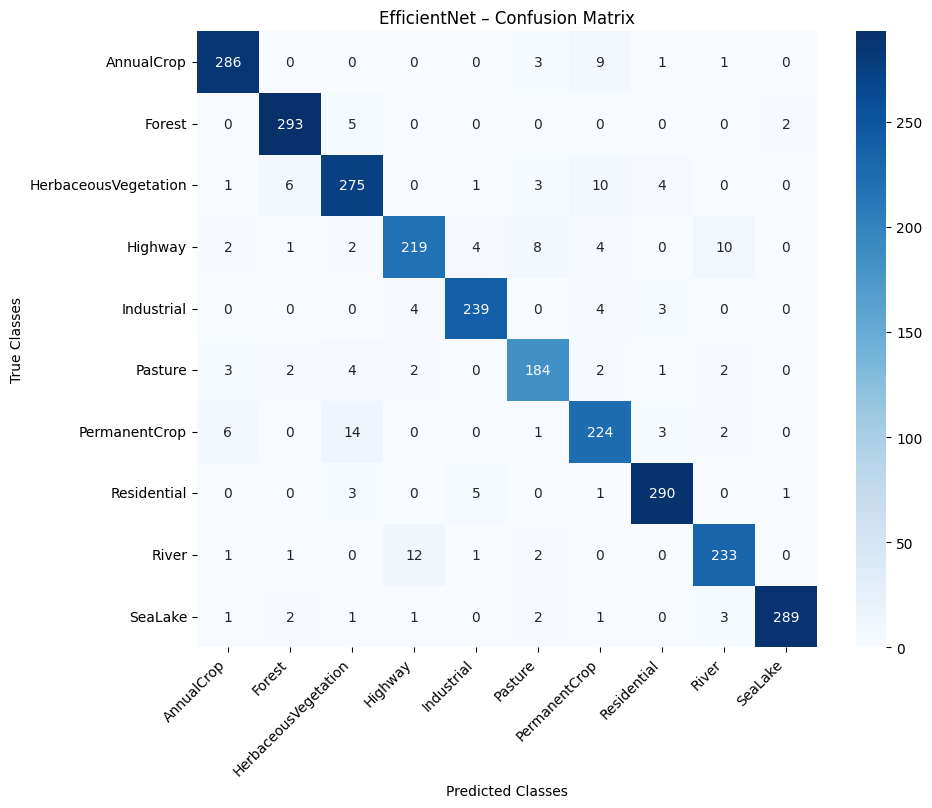

In [ ]:
results = {}

results["LeNet"] = full_evaluation(
    lenet_model, test_loader, ClassName, device, "LeNet"
)

results["ResNet18"] = full_evaluation(
    resnet_model, test_loader, ClassName, device, "ResNet18"
)

results["EfficientNet"] = full_evaluation(
    efficientnet_model, test_loader, ClassName, device, "EfficientNet"
)


**LENET metrics**:
For most of the classes precision and recall values are similar; they are not in the Highway and in the Residential.

*   In the Highway class, by observing that the Precision score is higher than the Recall score, it's shown that the false negatives are much higher than the false positives. This aspect can be verified by the confusion matrix, referring at the Highway's row.
*   In the Residential class, the situation is the opposite: the Residential's row of the confusion matrix shows that the values are basically all correct; the column instead shows that there are misclassified values.

The overall performance is not well enough miscalssifying around 1 image out of 5.

**RESNET18 metrics**:
There is no much difference between the precision and recall values, and the performances are very good.

**EFFICIENTNET-B0 metrics**:
There is just a slightly difference between precision and recall values, especially in the Highway class.
The results can still be considered good.

# **8. Model Comparison and Best Model Selection**

In [ ]:
summary = pd.DataFrame({
    "Model": results.keys(),
    "Accuracy": [results[m][0] for m in results],
    # Estraiamo la Precision (macro media)
    "Macro Precision": [
        results[m][1].loc["macro avg", "precision"]
        for m in results
    ],
    # Estraiamo la Recall (macro media)
    "Macro Recall": [
        results[m][1].loc["macro avg", "recall"]
        for m in results
    ],
    # Estraiamo l'F1-Score (macro media)
    "Macro F1": [
        results[m][1].loc["macro avg", "f1-score"]
        for m in results
    ],
    # Opzionale: Weighted F1 (tiene conto del numero di campioni per classe)
    "Weighted F1": [
        results[m][1].loc["weighted avg", "f1-score"]
        for m in results
    ]
})

# Ordina i risultati per Accuratezza decrescente per una lettura migliore
summary = summary.sort_values(by="Accuracy", ascending=False)
print(summary)

summary.style.background_gradient(cmap='RdYlGn')


          Model  Accuracy  Macro Precision  Macro Recall  Macro F1  \
1      ResNet18  0.965185         0.964373      0.962533  0.963286   
2  EfficientNet  0.937778         0.935788      0.935667  0.935629   
0         LeNet  0.854074         0.850205      0.849267  0.848212   

   Weighted F1  
1     0.965122  
2     0.937790  
0     0.852474  


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
1,ResNet18,0.965185,0.964373,0.962533,0.963286,0.965122
2,EfficientNet,0.937778,0.935788,0.935667,0.935629,0.937790
0,LeNet,0.854074,0.850205,0.849267,0.848212,0.852474


##  *Best Model Selection*

The comparison of the three models highlights a clear performance difference.

- **LeNet** achieves an accuracy of **85.4%** and a macro F1-score of **84.8%**.  
  As a baseline model, it provides a reasonable performance but struggles to capture complex spatial patterns present in satellite images.

- **ResNet18** delivers the best results, with an accuracy of **96.5%** and a macro F1-score of **96.3%**.  
  The strong improvement over LeNet shows that deeper architectures with residual connections are highly effective for this task.

- **EfficientNetB0** also performs very well, reaching an accuracy of **93.8%** and a macro F1-score of **93.6%**.  
  While slightly less accurate than ResNet18, it offers a good trade-off between performance and model efficiency.


=> Based on these results, **ResNet18** is selected as the final model for this project. It achieves the highest accuracy and macro F1-score. Its high macro F1-score confirms that it performs consistently well across all land-use classes, which is particularly important for balanced multi-class classification.





# **9. Prediction Results**

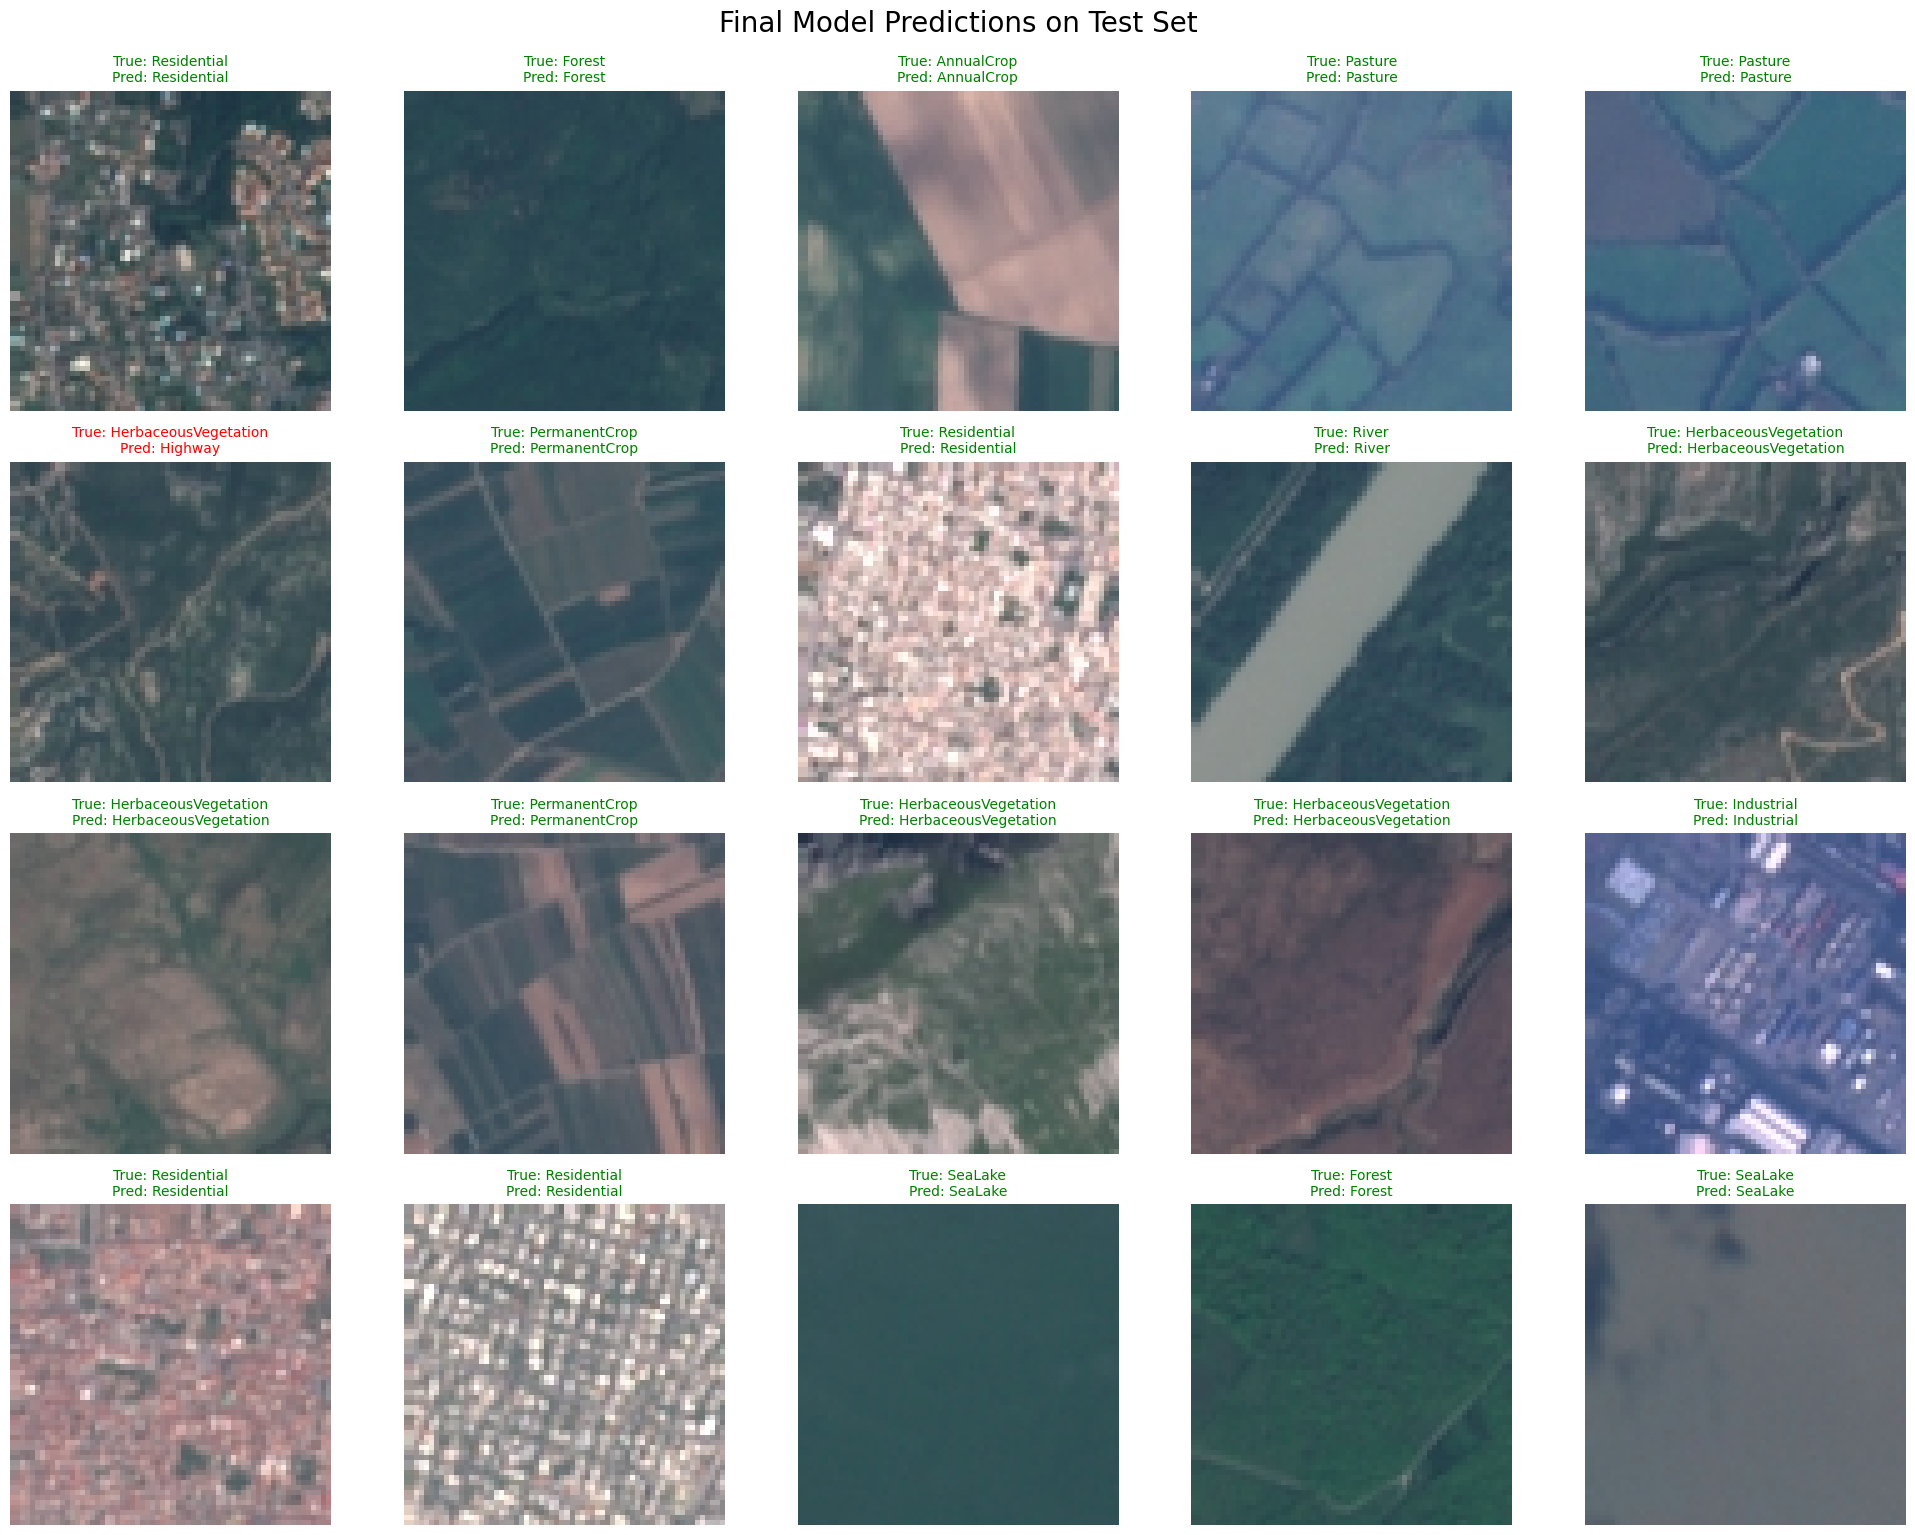

In [ ]:
import random

# 1. Scegli quale modello testare (es. resnet_model, efficientnet_model o lenet_model)
model_to_test = resnet_model
model_to_test.eval()

# 2. Seleziona 20 indici casuali dal test set
num_samples = 20
random_indices = random.sample(range(len(test_dataset)), num_samples)

# Inversione della normalizzazione per la visualizzazione
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

# 3. Creazione della griglia (4 righe x 5 colonne)
plt.figure(figsize=(20, 15))

with torch.no_grad():
    for i, idx in enumerate(random_indices):
        image, label = test_dataset[idx]

        # Predizione
        input_tensor = image.unsqueeze(0).to(device)
        outputs = model_to_test(input_tensor)
        _, preds = torch.max(outputs, 1)

        predicted_class = test_class_names[preds.item()]
        true_class = test_class_names[label]

        # Denormalizzazione dell'immagine per il plot
        img_display = image.permute(1, 2, 0).cpu().numpy()
        img_display = std * img_display + mean
        img_display = np.clip(img_display, 0, 1)

        # Plotting
        plt.subplot(4, 5, i + 1)
        plt.imshow(img_display)

        # Colore verde se corretto, rosso se sbagliato
        color = 'green' if predicted_class == true_class else 'red'

        plt.title(f"True: {true_class}\nPred: {predicted_class}", color=color, fontsize=10)
        plt.axis('off')

plt.tight_layout()
plt.suptitle(f"Final Model Predictions on Test Set", fontsize=20, y=1.02)
plt.show()

This visualization provides a qualitative assessment of the ResNet18's performance. The high frequency of correct predictions (in green) confirms that the model has successfully learned to generalize land-use features across different orientations. The rare misclassifications (in red) typically occur between classes with high visual similarity.

# **10. Conclusion and Perspectives**



This study successfully implemented and compared different CNN architectures for land-use classification using the EuroSAT dataset. ResNet18 emerged as the most reliable model with a 96.5% accuracy. A key takeaway is the importance of geometric data augmentation in satellite imagery to handle rotational invariance. Future developments could involve the use of multi-spectral bands (beyond RGB) to further reduce ambiguity between classes with similar spectral signatures, such as herbaceous vegetation and water bodies.